In [75]:
import numpy as np
import matplotlib.pyplot as plt
from Stochastic.Algorithms.ucb import UCB
from Stochastic.Algorithms.kl_ucb import KLUCB
from Stochastic.Algorithms.epsilon_t_greedy import EpsilonTGreedy
from Adversarial.Algorithms.exp3 import EXP3

from Stochastic.Rewards.gaussian import GaussianReward
from Stochastic.utils import cal_regret, plot_regret

In [76]:
from importlib import reload
from Stochastic.Algorithms import ucb
reload(ucb)
UCB = ucb.UCB

In [77]:
def run_experiment(algorithms, distributions, T):
    """
    Run experiment for duration of T steps.

    Args:
        algorithm: List of algorithms to evaluate.
        distributions: List of reward distributions for each arm.
        T: Number of time steps to run the experiment.
    Returns:
        rewards: Dictionary mapping algorithm names to their reward history.
    """
    
    actions = {alg.name: np.zeros(T, dtype=int) for alg in algorithms} # Store rewards per algorithm.
    rewards = {alg.name: np.zeros(T) for alg in algorithms} # Store rewards per algorithm.

    for alg in algorithms:
        for t in range(T):
            arm = alg.select_arm()
            reward = distributions[arm].pull()
            
            actions[alg.name][t] = arm
            rewards[alg.name][t] = reward

            alg.update(arm, reward)
            
    return actions, rewards

# Environment 1 (Stationary)
No of arms = 2<br>
Dist1 = Gausian(1, 1)<br>
Dist2 = Gausian(2, 1)<br>
T = 1000

In [78]:
# Environment 1 (Stationary)
n_arms = 2
dist1 = GaussianReward(1, 1) # Distribution of rewards for arm 1
dist2 = GaussianReward(1.001, 1) # Distribution of rewards for arm 2
T = 100000 # Time horizon

In [79]:
args = {'C': 2}
ucb = UCB(n_arms, args)
kl_ucb = KLUCB(n_arms, sigma=1)
eps_t_greedy = EpsilonTGreedy(n_arms)

In [80]:
algorithms = [ucb, kl_ucb, eps_t_greedy]
distributions = [dist1, dist2]

actions, _ = run_experiment(algorithms, distributions, T)

In [81]:
# Calculate regret for each algorithm
ucb_regret = cal_regret(reward_distributions=distributions, hist=actions['ucb'])
kl_ucb_regret = cal_regret(reward_distributions=distributions, hist=actions['kl_ucb'])
eps_greedy_regret = cal_regret(reward_distributions=distributions, hist=actions['eps_t_greedy'])

In [82]:
regret_dict = {'ucb': ucb_regret, 'kl_ucb': kl_ucb_regret, 'eps_t_greedy': eps_greedy_regret}

In [83]:
def plot_regret(regret_dict, marker_spacing=20):
    """
    Plot the cumulative regret for different algorithms.
    Parameters:
        regret_dict (dict): algo_name -> cumulative_regret
    """
    plt.figure(figsize=(10, 6))
    # Plot marker at regular intervals
    marker_style = ["o", "*", "^", "s", "D"]
    for k, (algo, regret) in enumerate(regret_dict.items()):
        plt.plot(regret, label=algo, marker=marker_style[k % len(marker_style)], markevery=marker_spacing, linestyle="-")

    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative Regret")
    plt.title("Cumulative Regret of Different Algorithms")
    plt.legend()
    plt.show()

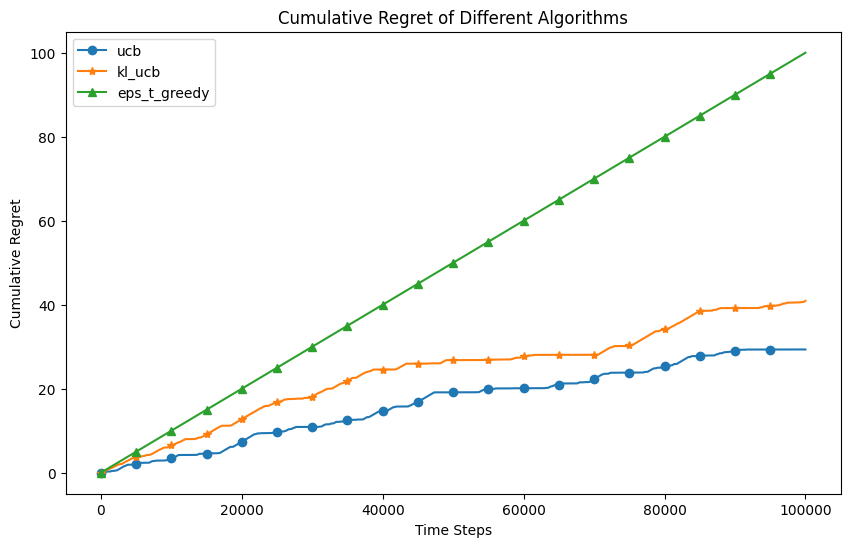

In [84]:
# Plotting the regret curves
plot_regret(regret_dict, marker_spacing=5000)

**Increase no. of arms**

In [100]:
n_arms = 10
ucb = UCB(n_arms, args)
kl_ucb = KLUCB(n_arms, sigma=1)
eps_t_greedy = EpsilonTGreedy(n_arms)

# Mean difference of 0.1 between arms
algorithms = [ucb, kl_ucb, eps_t_greedy]
distributions = [GaussianReward(1 + i * 0.01, 2) for i in range(n_arms)]

In [101]:
actions, _ = run_experiment(algorithms, distributions, T)

In [102]:
# Calculate regret for each algorithm
ucb_regret = cal_regret(reward_distributions=distributions, hist=actions['ucb'])
kl_ucb_regret = cal_regret(reward_distributions=distributions, hist=actions['kl_ucb'])
eps_greedy_regret = cal_regret(reward_distributions=distributions, hist=actions['eps_t_greedy'])

In [103]:
regret_dict = {'ucb': ucb_regret, 'kl_ucb': kl_ucb_regret, 'eps_t_greedy': eps_greedy_regret}

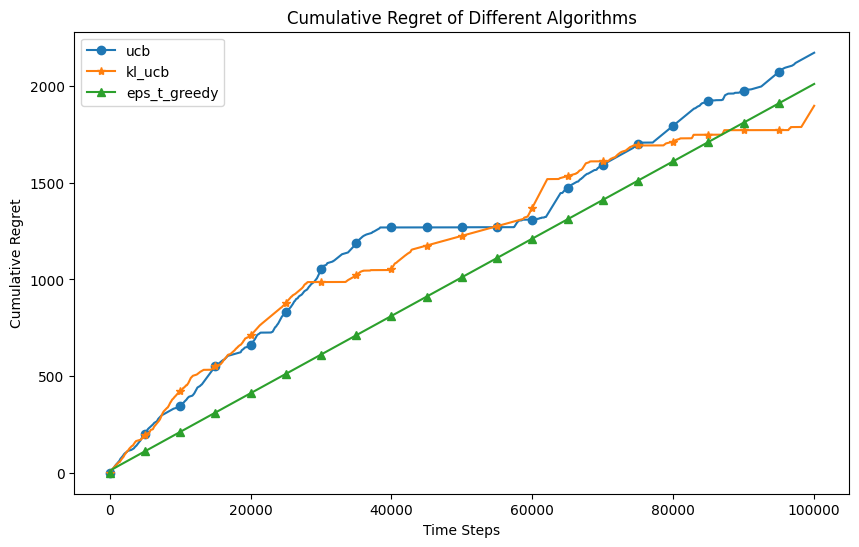

In [104]:
plot_regret(regret_dict, marker_spacing=5000)

**Adversarial Environment**

In [107]:
from Adversarial.Algorithms.exp3 import EXP3

In [170]:
def run_experiment(alg, T):
    """
    Run experiment for duration of T steps.

    Args:
        algorithm: List of algorithms to evaluate.
        distributions: List of reward distributions for each arm.
        T: Number of time steps to run the experiment.
    Returns:
        rewards: Dictionary mapping algorithm names to their reward history.
    """
    prob_hist = np.zeros((T, alg.K))
    reward_hist = np.zeros((T, alg.K))
    for t in range(T):
        arm = alg.select_arm()
        rewards = 1 / alg.probs
        rewards = rewards / rewards.sum()

        alg.update(arm, rewards[arm])

        prob_hist[t] = alg.probs
        reward_hist[t] = rewards
        
    return prob_hist, reward_hist

In [171]:
n_arms = 4
args = {"gamma": 0.1}
exp3 = EXP3(K=n_arms, args=args)

In [172]:
T = 1000000
action_hist, reward_hist = run_experiment(exp3, T)

In [173]:
# Calculate regret for exp3
sum_rewards = np.cumsum(reward_hist, axis=0)
best_arm_cum_reward = sum_rewards.max(axis=1)

In [174]:
expected_rewards = np.array([np.dot(prob, rewards) for prob, rewards in zip(action_hist, reward_hist)])
expected_cum_rewards = np.cumsum(expected_rewards)

In [175]:
regret = best_arm_cum_reward - expected_cum_rewards

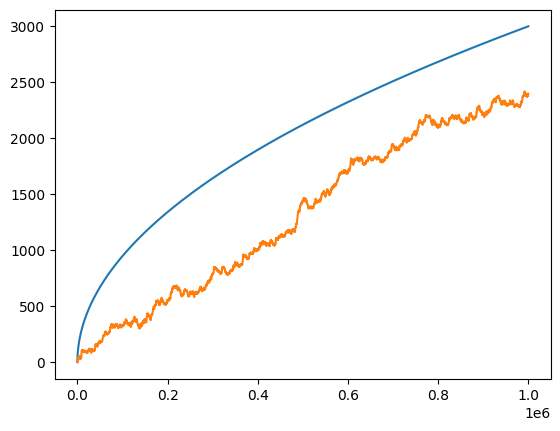

In [179]:
plt.plot(3*np.sqrt(np.arange(1, T+1)))
plt.plot(regret)

array([[0.77570021, 0.74895886, 0.75639741, 0.71894352],
       [0.77950242, 0.73610118, 0.76056788, 0.72382853],
       [0.78317978, 0.72366569, 0.76460141, 0.72855313],
       ...,
       [0.70398503, 0.7947008 , 0.78561294, 0.71570124],
       [0.70939173, 0.78034288, 0.78939118, 0.72087421],
       [0.7146222 , 0.76645298, 0.79304627, 0.72587856]])

In [166]:
expected_rewards

array([0.74833298, 0.7481398 , 0.74753244, ..., 0.74343977, 0.7450303 ,
       0.74604289])

In [167]:
reward_hist.max(axis=1)

array([0.77570021, 0.77950242, 0.78317978, ..., 0.7947008 , 0.78939118,
       0.79304627])

In [168]:
0.04 * (10**6)

40000.0

In [169]:
np.sqrt(10**6)

1000.0